# N03 — Figure 2: deterministic experiment and resistance diagnostic

The measured oscilloscope traces are reconstructed as charge, current, and energy and compared with two dynamical descriptions:

1. the measured trajectory reconstructed from $V_C$ and $V_R$;
2. the component-level prediction using $R_{\rm comp}$;
3. the fit-window resistance diagnostic $R_{\rm dyn}$.

The observed crossing comes directly from the measured traces.  The fitted resistance is used only to examine sensitivity of the predicted dynamics; it is not a confidence interval or an independent calibration.


In [1]:
from pathlib import Path
import json, csv, re, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Locate the project root from the notebook directory or its parents.
def locate_root(start=Path.cwd()):
    candidates = [start, start.parent, start.parent.parent]
    for p in candidates:
        if (p / "experimental_data" / "raw").exists():
            return p.resolve()
    raise FileNotFoundError("Could not locate the project directory containing experimental_data/raw/." )

ROOT = locate_root()
RAW = ROOT / "experimental_data" / "raw"
REF = ROOT / "experimental_data" / "reference"
OUT_DATA = ROOT / "notebook_outputs" / "data"
OUT_FIG = ROOT / "notebook_outputs" / "figures"
OUT_DATA.mkdir(parents=True, exist_ok=True)
OUT_FIG.mkdir(parents=True, exist_ok=True)

# ---------------- Plot-style switch ----------------
# Safe default: executes everywhere with Matplotlib only.
# Local options:
#   PLOT_STYLE = "science-no-latex"  -> requires `pip install scienceplots`
#   PLOT_STYLE = "science-latex"     -> additionally requires a local LaTeX install
PLOT_STYLE = "matplotlib"

def apply_plot_style(style=PLOT_STYLE):
    plt.style.use("default")
    if style.startswith("science"):
        try:
            import scienceplots  # noqa: F401
            plt.style.use(["science", "no-latex"] if style == "science-no-latex" else ["science"])
        except ImportError:
            warnings.warn("scienceplots is not installed; falling back to Matplotlib.")
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 9.0,
        "axes.labelsize": 9.0,
        "axes.titlesize": 9.5,
        "legend.fontsize": 7.5,
        "xtick.labelsize": 8.0,
        "ytick.labelsize": 8.0,
        "axes.linewidth": 0.7,
        "lines.linewidth": 1.3,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.04,
    })

apply_plot_style()

# Measured/component values used in the manuscript.
L_H = 44.4e-3
C_F = 454e-6
R_EXT_OHM = 22.2
R_COMP_OHM = 27.9
DETERMINISTIC_RELEASE_S = 7.2e-3

print("Data files located successfully.")
print(f"Plot style: {PLOT_STYLE}")


Data files located successfully.
Plot style: matplotlib


In [2]:
def sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def read_scope_csv(path):
    """Read the two Tektronix channel blocks stored side-by-side in one CSV."""
    path = Path(path)
    rows = list(csv.reader(path.open(newline="", encoding="utf-8", errors="ignore")))
    channels = {}
    for block_start in (0, 6):
        metadata = {}
        for row in rows[:20]:
            if len(row) > block_start + 1 and row[block_start].strip():
                metadata[row[block_start].strip()] = row[block_start + 1].strip()
        n = int(round(float(metadata["Record Length"])))
        dt = float(metadata["Sample Interval"])
        trigger = float(metadata["Trigger Point"])
        values = []
        for row in rows:
            if len(row) > block_start + 4:
                try:
                    values.append(float(row[block_start + 4]))
                except ValueError:
                    pass
        values = np.asarray(values, dtype=float)
        assert len(values) == n, (path.name, block_start, len(values), n)
        time_s = (np.arange(n, dtype=float) - trigger) * dt
        source = metadata.get("Source", f"CH{len(channels)+1}")
        channels[source] = {
            "time_s": time_s,
            "values": values,
            "metadata": metadata,
            "dt_s": dt,
        }
    assert set(channels) == {"CH1", "CH2"}
    assert np.allclose(channels["CH1"]["time_s"], channels["CH2"]["time_s"])
    return channels


def reconstruct_scope(path, release_shift_s=None):
    channels = read_scope_csv(path)
    t_trigger = channels["CH1"]["time_s"]
    vc = channels["CH1"]["values"]
    vr = channels["CH2"]["values"]
    current = -vr / R_EXT_OHM
    charge = C_F * vc
    energy = 0.5 * C_F * vc**2 + 0.5 * L_H * current**2
    frame = pd.DataFrame({
        "time_after_trigger_s": t_trigger,
        "Vc_V": vc,
        "Vr_V": vr,
        "q_C": charge,
        "I_A": current,
        "E_J": energy,
    })
    if release_shift_s is not None:
        frame.insert(1, "time_after_release_s", t_trigger - release_shift_s)
    return frame, channels


def first_crossing(t1, e1, t2, e2, start_s=0.0):
    """First sign change of e1-e2, with linear interpolation."""
    t1 = np.asarray(t1); e1 = np.asarray(e1); t2 = np.asarray(t2); e2 = np.asarray(e2)
    mask = (t1 >= start_s) & (t1 <= t2[-1])
    tx = t1[mask]
    d = e1[mask] - np.interp(tx, t2, e2)
    idx = np.where(np.diff(np.signbit(d)))[0]
    if len(idx) == 0:
        return np.nan, np.nan
    i = int(idx[0])
    tc = tx[i] - d[i] * (tx[i+1] - tx[i]) / (d[i+1] - d[i])
    ec = float(np.interp(tc, tx, e1[mask]))
    return float(tc), ec


## 1. Reconstruct the two deterministic traces directly from raw files


In [3]:
DET = RAW/"deterministic"
slow,_ = reconstruct_scope(DET/"alento_02(1).csv", release_shift_s=DETERMINISTIC_RELEASE_S)
fast,_ = reconstruct_scope(DET/"arapido_02(1).csv", release_shift_s=DETERMINISTIC_RELEASE_S)

tx_data, Ex_data = first_crossing(fast["time_after_release_s"],fast["E_J"],slow["time_after_release_s"],slow["E_J"])
print(f"measured crossing = {1e3*tx_data:.6f} ms at {1e6*Ex_data:.3f} uJ")


measured crossing = 1.898250 ms at 165.862 uJ


## 2. Dynamical resistance and fit-window sensitivity

The supplied 225-point table records the resistance obtained over the tested fit windows.  The notebook reads this table directly because the original fitting objective and weighting convention are not reconstructed here.  Its role is limited to the sensitivity analysis shown in Fig. 2(c); the range is not interpreted as a confidence interval or as an independently calibrated resistance.


In [4]:
fit_audit=pd.read_csv(REF/"fit_window_scan.csv")
Rdyn=float(fit_audit["R_fit_ohm"].median())
R16,R84=np.percentile(fit_audit["R_fit_ohm"],[16,84])
Rmin,Rmax=fit_audit["R_fit_ohm"].min(),fit_audit["R_fit_ohm"].max()
print(f"R_dyn median = {Rdyn:.6f} ohm")
print(f"16–84% fit-window sensitivity = {R16:.6f}–{R84:.6f} ohm")
print(f"full tested range = {Rmin:.6f}–{Rmax:.6f} ohm")

reference_values=json.loads((REF/"reported_analysis_values.json").read_text())
assert abs(Rdyn-reference_values["noiseless"]["R_joint_fit_median_ohm"])<1e-10
assert abs(Rmin-reference_values["noiseless"]["R_joint_fit_tested_min_ohm"])<1e-10
assert abs(Rmax-reference_values["noiseless"]["R_joint_fit_tested_max_ohm"])<1e-10


R_dyn median = 33.077217 ohm
16–84% fit-window sensitivity = 32.493998–33.521264 ohm
full tested range = 32.070176–34.096738 ohm


## 3. Propagate the measured release states

Both model curves start from the measured release state. Only the total series resistance is changed. This isolates the role of the dynamical decay rates from the initial-state reconstruction.


In [5]:
def A_of(R):
    return np.array([[0.,1.],[-1/(L_H*C_F),-R/L_H]])

def initial_state(frame):
    i=frame["time_after_release_s"].abs().idxmin()
    return float(frame.loc[i,"q_C"]),float(frame.loc[i,"I_A"]),float(frame.loc[i,"E_J"])

def theory_from_state(q0,I0,t,R):
    A=A_of(R); x0=np.array([q0,I0])
    X=np.array([expm(A*tt)@x0 for tt in t])
    q=X[:,0]; I=X[:,1]
    return q/C_F,I,0.5*q*q/C_F+0.5*L_H*I*I

qs0,Is0,Es0=initial_state(slow)
qf0,If0,Ef0=initial_state(fast)
t_theory=np.linspace(0,0.030,1600)
vcs_d,Is_d,Es_d=theory_from_state(qs0,Is0,t_theory,Rdyn)
vcf_d,If_d,Ef_d=theory_from_state(qf0,If0,t_theory,Rdyn)
vcs_c,Is_c,Es_c=theory_from_state(qs0,Is0,t_theory,R_COMP_OHM)
vcf_c,If_c,Ef_c=theory_from_state(qf0,If0,t_theory,R_COMP_OHM)


### Predicted crossing versus resistance

The third panel is deliberately a diagnostic plot. It asks how the predicted crossing would shift if the effective total series resistance changed while the measured release states were held fixed.


In [6]:
def crossing_for_R(R):
    _,_,es=theory_from_state(qs0,Is0,t_theory,R)
    _,_,ef=theory_from_state(qf0,If0,t_theory,R)
    d=ef-es
    idx=np.where(np.diff(np.signbit(d)))[0]
    if not len(idx): return np.nan
    i=idx[0]
    return t_theory[i]-d[i]*(t_theory[i+1]-t_theory[i])/(d[i+1]-d[i])

Rgrid=np.linspace(24,38,240)
tcross=np.array([crossing_for_R(R) for R in Rgrid])
print(f"component-model crossing: {1e3*crossing_for_R(R_COMP_OHM):.3f} ms")
print(f"dynamic-model crossing:   {1e3*crossing_for_R(Rdyn):.3f} ms")


component-model crossing: 2.185 ms
dynamic-model crossing:   1.881 ms


## 4. Regenerate Figure 2

The style is controlled only by the configuration cell at the top. On a local machine, change `PLOT_STYLE` to `science-no-latex` or `science-latex` for a SciencePlots/LaTeX rendering without touching the physics code.


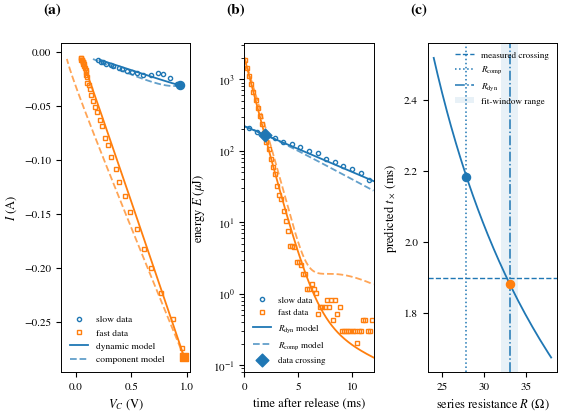

In [7]:
cycle=mpl.rcParams["axes.prop_cycle"].by_key()["color"]
SLOW,FAST=cycle[0],cycle[1]
fig=plt.figure(figsize=(6.4,4.28))
gs=fig.add_gridspec(1,3,wspace=0.42)
ax1,ax2,ax3=[fig.add_subplot(gs[0,i]) for i in range(3)]

def panel(ax,label):
    ax.text(-0.14,1.08,label,transform=ax.transAxes,fontweight="bold",fontsize=11,va="bottom")

# (a) phase-space trajectories
ms=(slow["time_after_release_s"]>=0)&(slow["time_after_release_s"]<=0.020)
mf=(fast["time_after_release_s"]>=0)&(fast["time_after_release_s"]<=0.006)
ax1.plot(slow.loc[ms,"Vc_V"].iloc[::3],slow.loc[ms,"I_A"].iloc[::3],ls="none",marker="o",mfc="none",mec=SLOW,ms=3,label="slow data")
ax1.plot(fast.loc[mf,"Vc_V"].iloc[::4],fast.loc[mf,"I_A"].iloc[::4],ls="none",marker="s",mfc="none",mec=FAST,ms=3,label="fast data")
mt=t_theory<=.020; mtf=t_theory<=.006
ax1.plot(vcs_d[mt],Is_d[mt],color=SLOW,label="dynamic model")
ax1.plot(vcf_d[mtf],If_d[mtf],color=FAST)
ax1.plot(vcs_c[mt],Is_c[mt],color=SLOW,ls="--",alpha=.7,label="component model")
ax1.plot(vcf_c[mtf],If_c[mtf],color=FAST,ls="--",alpha=.7)
ax1.scatter([slow.loc[slow["time_after_release_s"].abs().idxmin(),"Vc_V"]],[Is0],s=34,color=SLOW,zorder=5)
ax1.scatter([fast.loc[fast["time_after_release_s"].abs().idxmin(),"Vc_V"]],[If0],s=34,color=FAST,marker="s",zorder=5)
ax1.set_xlabel(r"$V_C$ (V)"); ax1.set_ylabel(r"$I$ (A)")
ax1.legend(frameon=False,fontsize=6.8,loc="lower left"); panel(ax1,"(a)")

# (b) energy crossing
ms=(slow["time_after_release_s"]>=0)&(slow["time_after_release_s"]<=.012)
mf=(fast["time_after_release_s"]>=0)&(fast["time_after_release_s"]<=.012)
ax2.plot(1e3*slow.loc[ms,"time_after_release_s"].iloc[::2],1e6*slow.loc[ms,"E_J"].iloc[::2],ls="none",marker="o",mfc="none",mec=SLOW,ms=3,label="slow data")
ax2.plot(1e3*fast.loc[mf,"time_after_release_s"].iloc[::5],1e6*fast.loc[mf,"E_J"].iloc[::5],ls="none",marker="s",mfc="none",mec=FAST,ms=3,label="fast data")
m=t_theory<=.012
ax2.plot(1e3*t_theory[m],1e6*Es_d[m],color=SLOW,label=r"$R_{\rm dyn}$ model")
ax2.plot(1e3*t_theory[m],1e6*Ef_d[m],color=FAST)
ax2.plot(1e3*t_theory[m],1e6*Es_c[m],color=SLOW,ls="--",alpha=.7,label=r"$R_{\rm comp}$ model")
ax2.plot(1e3*t_theory[m],1e6*Ef_c[m],color=FAST,ls="--",alpha=.7)
ax2.scatter(1e3*tx_data,1e6*Ex_data,s=42,marker="D",color=SLOW,zorder=6,label="data crossing")
ax2.set_yscale("log"); ax2.set_xlim(0,12)
ax2.set_xlabel("time after release (ms)"); ax2.set_ylabel(r"energy $E$ ($\mu$J)")
ax2.legend(frameon=False,fontsize=6.5,loc="lower left"); panel(ax2,"(b)")

# (c) resistance diagnostic
ax3.plot(Rgrid,1e3*tcross)
ax3.axhline(1e3*tx_data,ls="--",lw=1.0,label="measured crossing")
ax3.axvline(R_COMP_OHM,ls=":",lw=1.1,label=r"$R_{\rm comp}$")
ax3.axvline(Rdyn,ls="-.",lw=1.1,label=r"$R_{\rm dyn}$")
ax3.axvspan(Rmin,Rmax,alpha=.10,label="fit-window range")
ax3.scatter(R_COMP_OHM,1e3*crossing_for_R(R_COMP_OHM),s=34,zorder=5)
ax3.scatter(Rdyn,1e3*crossing_for_R(Rdyn),s=34,zorder=5)
ax3.set_xlabel(r"series resistance $R$ ($\Omega$)"); ax3.set_ylabel(r"predicted $t_\times$ (ms)")
ax3.legend(frameon=False,fontsize=6.6); panel(ax3,"(c)")

fig.savefig(OUT_FIG/"Figure2_deterministic_crossing_reproduced.pdf")
fig.savefig(OUT_FIG/"Figure2_deterministic_crossing_reproduced.png",dpi=300)
plt.show()


### Interpretation

- **Panel (a):** the measured slow and fast preparations occupy different directions in phase space, and the dynamical model follows the observed trajectories more closely than the component-only estimate.
- **Panel (b):** the fast preparation begins with more stored energy but crosses below the slow preparation while both continue to dissipate energy.
- **Panel (c):** the predicted crossing time changes with the effective series resistance; the shaded span shows fit-window sensitivity rather than statistical uncertainty.


## 5. Check against reported values

The measured crossing and the resistance-sensitivity summary are compared with the reference values used in the manuscript.  Plot appearance may vary with fonts or PDF metadata; the numerical quantities are checked directly.


In [8]:
checks={
    "measured_crossing_ms": (1e3*tx_data, reference_values["noiseless"]["crossing_ms"], 3e-4),
    "Rdyn_median_ohm": (Rdyn, reference_values["noiseless"]["R_joint_fit_median_ohm"], 1e-9),
    "R_window_min_ohm": (Rmin, reference_values["noiseless"]["R_joint_fit_tested_min_ohm"], 1e-9),
    "R_window_max_ohm": (Rmax, reference_values["noiseless"]["R_joint_fit_tested_max_ohm"], 1e-9),
}
rows=[]
for name,(x,y,tol) in checks.items():
    rows.append([name,x,y,abs(x-y),tol,abs(x-y)<=tol])
reg=pd.DataFrame(rows,columns=["quantity","reproduced","reference","abs_difference","tolerance","PASS"])
display(reg)
assert reg.PASS.all()
print("N03 numerical check: PASS")


,quantity,reproduced,reference,abs_difference,tolerance,PASS
0,measured_crossing_ms,1.898250,1.898241,0.000009,3.000000e-04,True
1,Rdyn_median_ohm,33.077217,33.077217,0.000000,1.000000e-09,True
2,R_window_min_ohm,32.070176,32.070176,0.000000,1.000000e-09,True
3,R_window_max_ohm,34.096738,34.096738,0.000000,1.000000e-09,True


N03 numerical check: PASS
